# 수식에 따라 선형회귀 구현

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# 입력 데이터와 목표값
x = np.array([2, 4, 6, 8], dtype=float)
y = np.array([81, 93, 91, 97], dtype=float)

# 초기값과 학습률
a = 0.0
b = 0.0
learning_rate = 0.01
epochs = 10000

In [7]:
def train_linear_regression(x, y, a, b, learning_rate, epochs):
    n = len(x)
    cost_history = []

    for epoch in range(epochs):
        prediction = a * x + b
        error = y - prediction

        cost = np.mean(error**2)
        cost_history.append(cost)
        gradient_a = -(2 / n) * np.sum(x * error)
        gradient_b = -(2 / n) * np.sum(error)

        a -= learning_rate * gradient_a
        b -= learning_rate * gradient_b

        if (epoch + 1) % 1000 == 0:
            print(
                f"epoch: {epoch + 1:5d}, "
                f"cost: {cost:.6f}, a: {a:.6f}, b: {b:.6f}"
            )

    return a, b, cost_history

In [8]:
a, b, cost_history = train_linear_regression(
    x, y, a, b, learning_rate, epochs
)

prediction = a * x + b
final_cost = np.mean((y - prediction) ** 2)

print("\n최종 결과")
print(f"직선의 방정식: y = {a:.6f}x + {b:.6f}")
print(f"최종 비용(MSE): {final_cost:.6f}")
print("예측값:", prediction)

epoch:  1000, cost: 9.780736, a: 2.797822, b: 76.029211
epoch:  2000, cost: 8.302235, a: 2.319341, b: 78.884584
epoch:  3000, cost: 8.300003, a: 2.300751, b: 78.995516
epoch:  4000, cost: 8.300000, a: 2.300029, b: 78.999826
epoch:  5000, cost: 8.300000, a: 2.300001, b: 78.999993
epoch:  6000, cost: 8.300000, a: 2.300000, b: 79.000000
epoch:  7000, cost: 8.300000, a: 2.300000, b: 79.000000
epoch:  8000, cost: 8.300000, a: 2.300000, b: 79.000000
epoch:  9000, cost: 8.300000, a: 2.300000, b: 79.000000
epoch: 10000, cost: 8.300000, a: 2.300000, b: 79.000000

최종 결과
직선의 방정식: y = 2.300000x + 79.000000
최종 비용(MSE): 8.300000
예측값: [83.6 88.2 92.8 97.4]


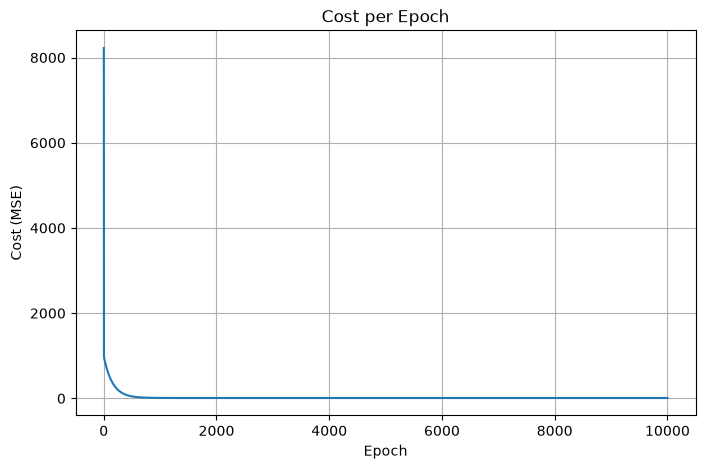

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), cost_history)
plt.xlabel("Epoch")
plt.ylabel("Cost (MSE)")
plt.title("Cost per Epoch")
plt.grid(True)
plt.show()

In [10]:
new_x = np.array([1, 3, 5, 7], dtype=float)
new_y = a * new_x + b

print("새 x 값:", new_x)
print("예측 y 값:", new_y)

새 x 값: [1. 3. 5. 7.]
예측 y 값: [81.3 85.9 90.5 95.1]


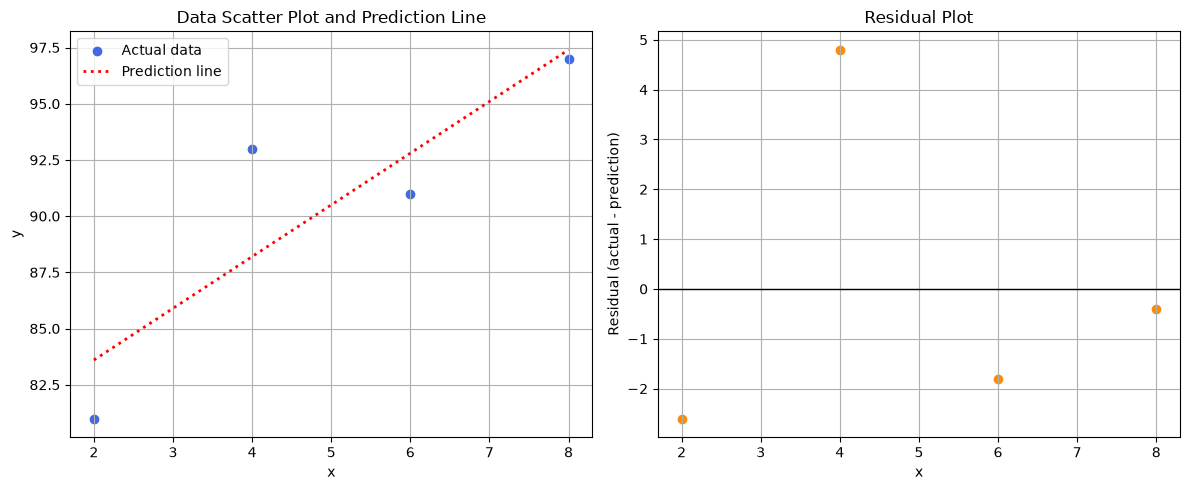

In [13]:
residual = y - prediction
line_x = np.linspace(x.min(), x.max(), 100)
line_y = a * line_x + b

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: data scatter plot and prediction line
axes[0].scatter(x, y, color="royalblue", label="Actual data")
axes[0].plot(line_x, line_y, "r:", linewidth=2, label="Prediction line")
axes[0].set_title("Data Scatter Plot and Prediction Line")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()
axes[0].grid(True)

# Right: residual plot
axes[1].scatter(x, residual, color="darkorange")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Residual Plot")
axes[1].set_xlabel("x")
axes[1].set_ylabel("Residual (actual - prediction)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Tensorflow를 이용한 선형회귀

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

I0000 00:00:1790120794.567729   30955 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790120795.799182   30955 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790120806.268024   30955 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
x_tf = np.array([2, 4, 6, 8], dtype=np.float32)
y_tf = np.array([81, 93, 91, 97], dtype=np.float32)

In [12]:
model = keras.Sequential([
    keras.layers.Input(shape=(1,)),
    keras.layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss="mse"
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    x_tf,
    y_tf,
    epochs=1000,
    verbose=0
)

최종 loss(MSE): 8.300009
예측값: [83.59995  88.199974 92.8      97.400024]
잔차: [-2.5999527  4.800026  -1.800003  -0.4000244]


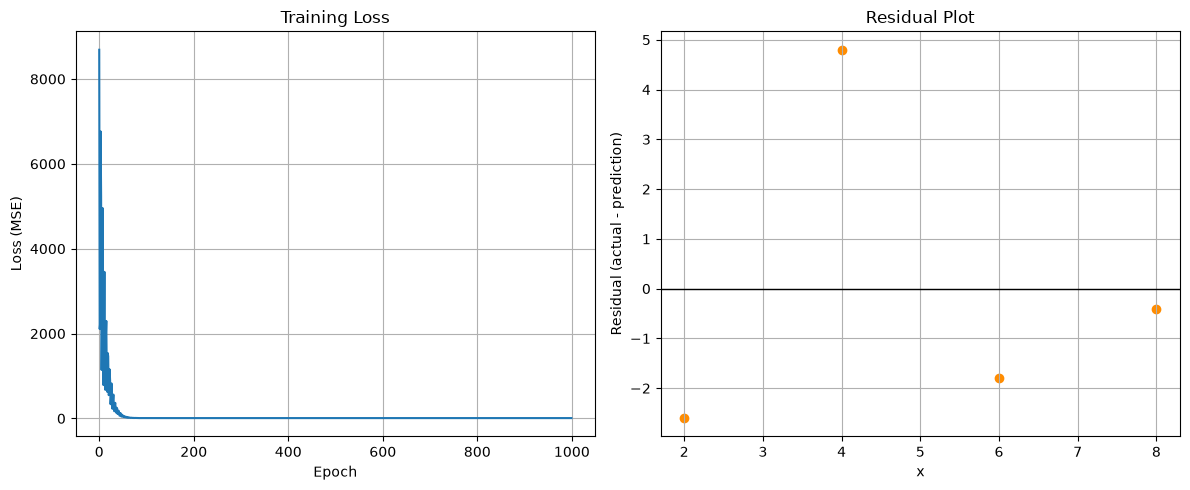

In [16]:
train_prediction = model.predict(x_tf, verbose=0).reshape(-1)
residual_tf = y_tf - train_prediction
final_loss = history.history["loss"][-1]

print(f"최종 loss(MSE): {final_loss:.6f}")
print("예측값:", train_prediction)
print("잔차:", residual_tf)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 왼쪽: 학습 loss
axes[0].plot(history.history["loss"])
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (MSE)")
axes[0].set_title("Training Loss")
axes[0].grid(True)

# 오른쪽: 잔차
axes[1].scatter(x_tf, residual_tf, color="darkorange")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("x")
axes[1].set_ylabel("Residual (actual - prediction)")
axes[1].set_title("Residual Plot")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [15]:
new_x_tf = np.array([1, 3, 5, 7], dtype=np.float32)
new_y_tf = model.predict(new_x_tf, verbose=0).reshape(-1)

print("입력 x:", new_x_tf)
print("예측 y:", new_y_tf)

입력 x: [1. 3. 5. 7.]
예측 y: [81.299934 85.89996  90.499985 95.10001 ]
